# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

## **Data validation**

**The original accounts table contained 400 rows and 6 columns. After validation, 357 rows remained. The following describes what was done to each column:**

- customer_id: The column had an object data type and contained the letter 'C' in the customer ID. It was converted to an integer and the letter was removed to enable joining with the support and activity tables.
- Email: There were 400 unique emails, matching the number of rows. The column contained no irregular values, and all emails followed a valid email format.
- State: Contains all 50 U.S. states with no spelling errors.
- Plan: Four plans are available: Enterprise, Basic, Free, and Pro.
- plan_list_price: Contains integer values ranging from 0 to 148, all within expected ranges.
- churn_status: Contained values 'Y' and 286 missing values (NaN), which indicate that the customer remained. Missing values were filled with 'N'.

**The original support table contained 918 rows and 7 columns. After validation, 781 rows remained. The following describes what was done to each column:**

- ticket_time: The data type was object and was converted to datetime.
- user_id: Contains IDs corresponding to the accounts table, with no missing values.
- channel: Four unique values were identified: 'chat', 'phone', '-', 'email'. The '-' value was replaced with 'Unknown'. The values were converted to Title Case to improve readability in visualizations.
- topic: Four unique values were identified: 'technical', 'account', 'other', 'billing'. Converted to Title Case for better readability in visualizations.
- resolution_time_hours: No negative values were found. The data type was correct, and values ranged from 0.52 to 32.46 hours.
- state: Name of this column duplicated the state names columns from the accounts table but contained binary values (0 and 1). It appeared to represent ticket status. Therefore, it was renamed to ticket_status, and values were mapped as follows: 1 → 'Resolved', 0 → 'Unresolved'.
- comments: Contained mostly empty values and 46 comments requesting data deletion. A total of 43 unique users were identified from these requests. These users were removed from all tables in compliance with data protection regulations. As a result, 781 rows remained.

**The original activity table contained 445 rows and 3 columns. After validation, 401 rows remained. The following describes what was done to each column:**

- event_time: The data type was object and was converted to datetime.
- user_id: Contains IDs corresponding to the accounts table, with no missing values.
- event_type: Four unique values were identified: 'watch_video', 'share_workout', 'read_article', 'track_workout'. Underscores were removed, and values were converted to Title Case for better readability in visualizations.

**Final result:** After data cleaning, which included removing data for 43 users who requested deletion, the dataset used for analysis contained 357 rows in accounts, 781 rows in support, and 401 rows in activity.

To begin with, I explored all three tables, determining the number of rows in each and reviewing the contents of the first rows of all columns. And renamed the tables for easier handling.



In [28]:
import pandas as pd

accounts = pd.read_csv('da_fitly_account_info.csv')
support = pd.read_csv('da_fitly_customer_support.csv')
activity = pd.read_csv('da_fitly_user_activity.csv')

# Проверяем, что данные загрузились (выведем размеры таблиц)
print(f"Number of rows loaded into accounts: {len(accounts)}")
print(f"Number of rows loaded into support: {len(support)}")
print(f"Number of rows loaded into activity: {len(activity)}")

# Посмотрим на кусочек данных
print(accounts.head())
print(support.head())
print(activity.head())

Number of rows loaded into accounts: 400
Number of rows loaded into support: 918
Number of rows loaded into activity: 445
  customer_id                  email  ... plan_list_price churn_status
0      C10000  user10000@example.com  ...             105            Y
1      C10001  user10001@example.net  ...              22            Y
2      C10002  user10002@example.net  ...              24          NaN
3      C10003  user10003@example.com  ...               0          NaN
4      C10004  user10004@example.com  ...             119          NaN

[5 rows x 6 columns]
                  ticket_time  user_id  ... state                          comments
0  2025-06-13 05:55:17.154573    10125  ...     1                               NaN
1  2025-08-06 13:21:54.539551    10109  ...     0                               NaN
2  2025-08-22 12:39:35.718663    10149  ...     0  Erase my data from your systems.
3  2025-06-07 02:49:46.986055    10268  ...     1                               NaN
4  2025-07

### Data quality and cleanliness check


In [29]:
# Checking for missing values

print(accounts.isnull().sum())
print(support.isnull().sum())
print(activity.isnull().sum())

# Checking data types

print(accounts.info())
print(support.info())
print(activity.info())

# Checking for uniqueness (duplicates)

print(accounts.duplicated().sum())
print(support.duplicated().sum())
print(activity.duplicated().sum())


customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64
event_time    0
user_id       0
event_type    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91

In [30]:
# Checking for unusual values in text fields

print(accounts['plan'].unique())
print(accounts['state'].unique())
print(accounts['churn_status'].unique())
print(accounts['plan_list_price'].unique())
print(accounts['plan_list_price'].max())
print(accounts['plan_list_price'].min())
print(accounts['email'].unique())
unique_emails = accounts['email'].nunique()
print(f"Number of unique emails: {unique_emails}")

print(support['channel'].unique())
print(support['topic'].unique())
print(support['comments'].unique())

print(activity['event_type'].unique())

print(support['resolution_time_hours'].describe())
print(support[support['resolution_time_hours'] < 0])

['Enterprise' 'Basic' 'Free' 'Pro']
['New Jersey' 'Louisiana' 'Oklahoma' 'Michigan' 'Texas' 'Ohio' 'Kentucky'
 'North Carolina' 'Alaska' 'Virginia' 'Kansas' 'Arizona' 'Idaho'
 'Connecticut' 'Colorado' 'Rhode Island' 'Maine' 'Wisconsin' 'Vermont'
 'Florida' 'Delaware' 'New York' 'Montana' 'Missouri' 'West Virginia'
 'New Mexico' 'Iowa' 'North Dakota' 'Hawaii' 'Nebraska' 'South Dakota'
 'Utah' 'Washington' 'Pennsylvania' 'Nevada' 'Arkansas' 'Illinois'
 'Wyoming' 'California' 'Tennessee' 'Minnesota' 'Maryland' 'Massachusetts'
 'Mississippi' 'South Carolina' 'Oregon' 'Georgia' 'Indiana' 'Alabama'
 'New Hampshire']
['Y' nan]
[105  22  24   0 119 114  19  10  87  51  57  93 104 110 138 100  16  64
  32  90  43  92  42 139  30  97  53 125 121 132 143  28 134  12  33  29
  95  99  17 140 115  79  49 137  61 131  71  73  20  60  62 147 111  26
  13  69 130  94 136 144  25 120  54  23  56 116 148  67  34  72  18  21
  27  91  14  50  80 112  15  48  37  77  45  78  81  39  35 118  65  66
 145 13

### Data cleaning

In [31]:
# Changing data types and removing the letter "C" from accounts customer_id

accounts['customer_id'] = accounts['customer_id'].astype(str).str.replace("C", "").astype(int)

# The Churn column contains 289 missing values, which means the customer stayed. These values need to be filled in

accounts['churn_status'] = accounts['churn_status'].fillna('N')

# In all tables, time is an object. Converting data types

support['ticket_time'] = pd.to_datetime(support['ticket_time'])
activity['event_time'] = pd.to_datetime(activity['event_time'])


In [32]:
#Renamed the 'state' column in the support table and converted it to text

support['state'] = support['state'].map({1: 'Resolved', 0 : 'Unresolved'})

support = support.rename(columns={'state' : 'ticket_status'})

In [33]:
#Renamed "-" in channel column

support['channel'] = support['channel'].replace({'-':'unknow'})
print(support['channel'].unique())

['chat' 'phone' 'unknow' 'email']


In [34]:
# Finding a list of all IDs who requested deletion (based on comments containing text)

delete_ids = support[support['comments'].notnull()]['user_id'].unique()
print(f"Users who wanted to leave: {len(delete_ids)}")

# Removing them from all tables in accordance with the law, which prohibits analyzing data from these users

accounts = accounts[~accounts['customer_id'].isin(delete_ids)]
support = support[~support['user_id'].isin(delete_ids)]
activity = activity[~activity['user_id'].isin(delete_ids)]

print(f"Users have been removed. Remaining rows in the support table: {len(support)}")

Users who wanted to leave: 43
Users have been removed. Remaining rows in the support table: 781


In [35]:
activity['event_type'] = activity['event_type'].str.replace('_', ' ').str.title()

support['channel'] = support['channel'].str.title()

support['topic'] = support['topic'].str.title()

### Data validation check after cleaning


In [36]:
# Checking for missing values

print(accounts.isnull().sum())
print(support.isnull().sum())
print(activity.isnull().sum())

# Checking data types

print(accounts.info())
print(support.info())
print(activity.info())

# Checking for uniqueness (duplicates)

print(accounts.duplicated().sum())
print(support.duplicated().sum())
print(activity.duplicated().sum())

customer_id        0
email              0
state              0
plan               0
plan_list_price    0
churn_status       0
dtype: int64
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
ticket_status              0
comments                 781
dtype: int64
event_time    0
user_id       0
event_type    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 357 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      357 non-null    int64 
 1   email            357 non-null    object
 2   state            357 non-null    object
 3   plan             357 non-null    object
 4   plan_list_price  357 non-null    int64 
 5   churn_status     357 non-null    object
dtypes: int64(2), object(4)
memory usage: 19.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 781 entries, 0

In [37]:
# Checking for unusual values in text fields

print(accounts['plan'].unique())
print(accounts['state'].unique())
print(accounts['churn_status'].unique())
print(accounts['plan_list_price'].unique())
print(accounts['plan_list_price'].max())
print(accounts['plan_list_price'].min())
print(accounts['email'].unique())
unique_emails = accounts['email'].nunique()
print(f"Number of unique emails: {unique_emails}")

print(support['channel'].unique())
print(support['topic'].unique())
print(support['comments'].unique())

print(activity['event_type'].unique())

print(support['resolution_time_hours'].describe())
print(support[support['resolution_time_hours'] < 0])

['Enterprise' 'Basic' 'Free' 'Pro']
['New Jersey' 'Louisiana' 'Oklahoma' 'Michigan' 'Texas' 'Ohio' 'Kentucky'
 'North Carolina' 'Alaska' 'Virginia' 'Kansas' 'Arizona' 'Idaho'
 'Connecticut' 'Colorado' 'Rhode Island' 'Maine' 'Vermont' 'Florida'
 'Delaware' 'New York' 'Montana' 'West Virginia' 'Iowa' 'North Dakota'
 'Hawaii' 'Nebraska' 'Missouri' 'South Dakota' 'Wisconsin' 'Utah'
 'Washington' 'Pennsylvania' 'Nevada' 'Arkansas' 'Illinois' 'Wyoming'
 'California' 'Tennessee' 'New Mexico' 'Minnesota' 'Maryland'
 'Massachusetts' 'Mississippi' 'Oregon' 'Georgia' 'South Carolina'
 'Indiana' 'Alabama' 'New Hampshire']
['Y' 'N']
[105  22  24   0 119 114  19  10  87  51  57  93 104 110 138 100  64  32
  90  43  92  42 139  30  97  53 125 121 132 143  28 134  12  16  33  29
  95  99  17 140 115  79  49 137  61 131  71  20  60  62 147 111  26  69
 130  94 136 144  25 120  54  56 116 148  67  13  34  72  18  73  21  27
  14  23  50  80 112  15  48  37  77  45  78  81  39  35 118  65  91  66
 145 13

In [38]:
# First, I will calculate the overall customer churn rate

churn_count = round(accounts['churn_status'].value_counts(normalize = True) *100, 1)

churn_count


N    72.8
Y    27.2
Name: churn_status, dtype: float64

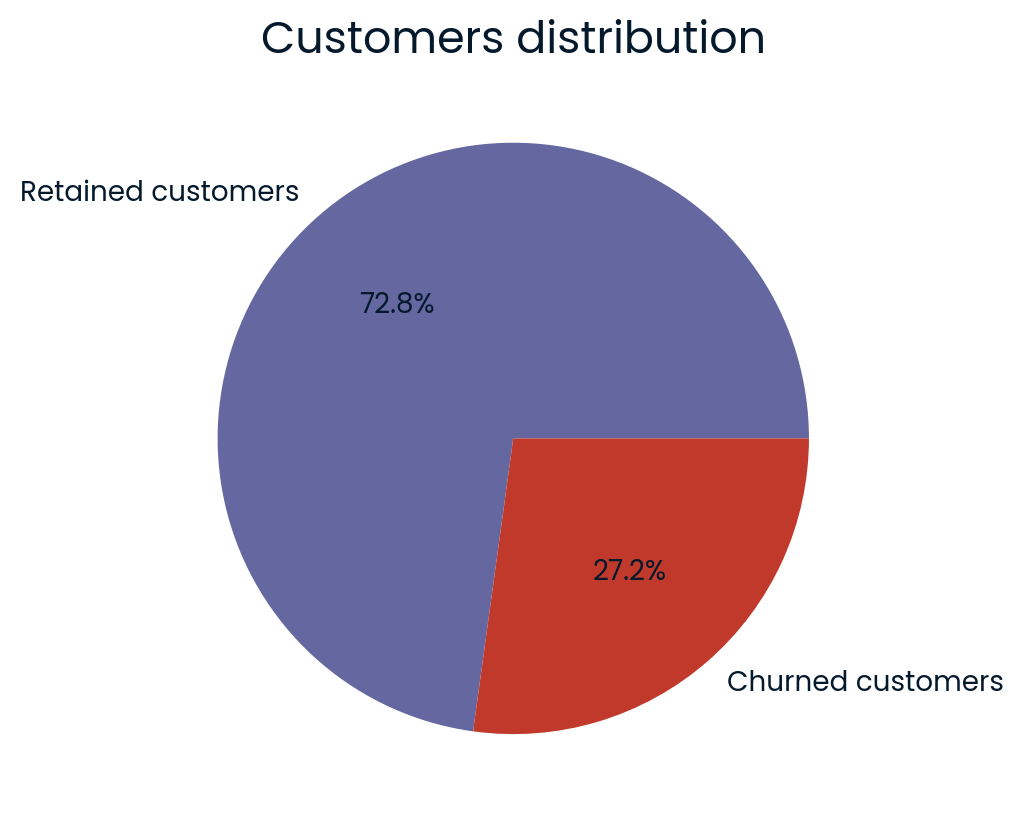

In [39]:
import matplotlib.pyplot as plt

churn_count = accounts['churn_status'].value_counts()
labels = ['Retained customers', 'Churned customers',]  
plt.pie(churn_count, labels=labels, autopct='%1.1f%%', colors = ['#6568A0', '#c0392b'])

plt.title('Customers distribution', fontsize=16)
plt.show()

The churn rate is 27.2%, meaning that roughly every fourth customer leaves.


In [40]:
-- 1. Hypothesis 1 - Plan cost.

-- How many people left each plan?
	
SELECT plan, COUNT(*) AS total_users_1
FROM accounts
WHERE churn_status = 'Y'
GROUP BY plan


,plan,total_users_1
0,Enterprise,22
1,Basic,25
2,Pro,14
3,Free,36


Visually, it seems that more customers leave from the free plan. However, I think we should focus on paying customers because, in total, more of them have churned. I want to know whether there is a correlation between customers who left and those who stayed, and the cost of their plan.


In [42]:
import duckdb as duckdb

price_corr = duckdb.query("""SELECT plan_list_price, churn_status,
plan
FROM accounts
WHERE plan IN ('Basic', 'Enterprise', 'Pro') """).to_df()



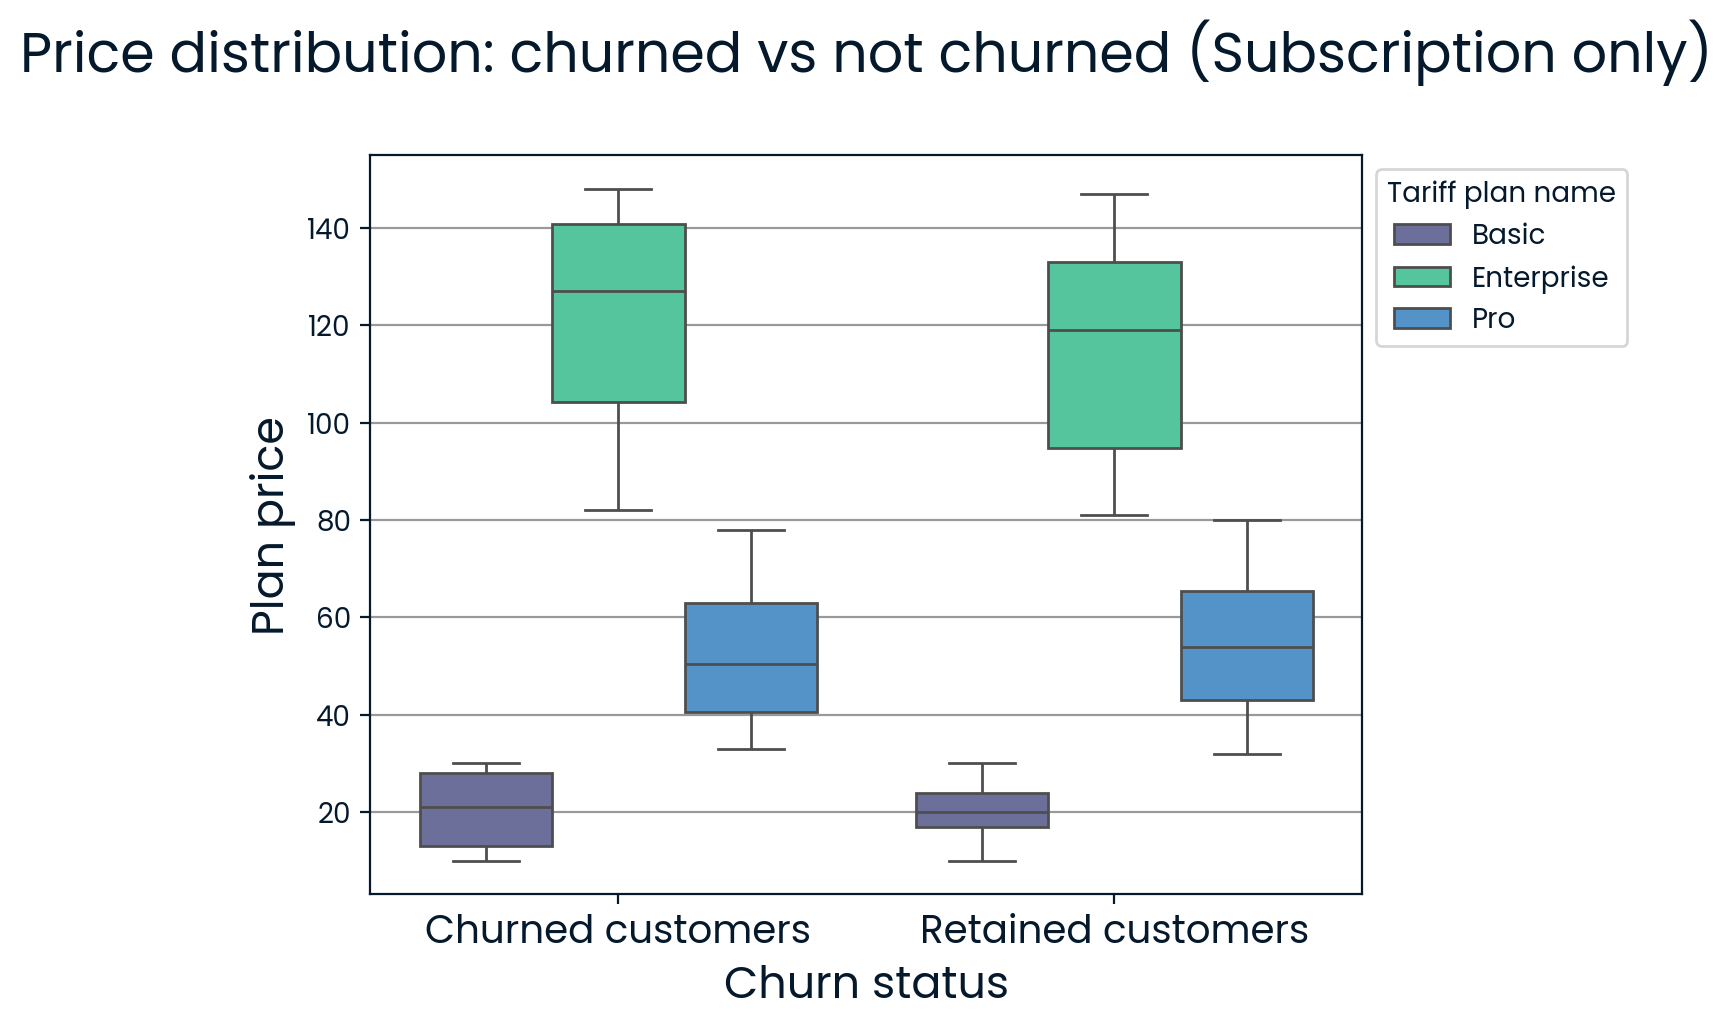

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.boxplot(
    data=price_corr,
    x='churn_status',
    y='plan_list_price',
    hue = 'plan'
    )

plt.title('Price distribution: churned vs not churned (Subscription only)', fontsize=20, pad=30)
plt.xlabel('Churn status', fontsize=16)
ax.set_xticklabels(['Churned customers', 'Retained customers'], fontsize=14)
plt.grid(axis='y', linestyle='-', alpha=0.4, color = 'black')
plt.legend( title = 'Tariff plan name', loc='upper left', bbox_to_anchor = (1,1)) 
plt.ylabel('Plan price', fontsize=16)

plt.show()


As can be seen from the graph, the price range is approximately the same for both churned and retained customers across all tariff plans. Therefore, I decided to merge all customers with paid subscriptions into a single group.


In [115]:
SELECT COUNT(DISTINCT customer_id) AS total_users, 
    CASE WHEN plan IN ('Basic', 'Enterprise', 'Pro') THEN 'Subscription'
    ELSE 'Free' END AS plan_group
    FROM accounts
    WHERE churn_status = 'Y'
    GROUP BY plan_group
    ORDER BY COUNT(DISTINCT customer_id) DESC

,total_users,plan_group
0,61,Subscription
1,36,Free


First, I decided to find out how the support service works.


In [118]:
#  Total number of unique users in the system (after GDPR)

total_users = accounts['customer_id'].nunique()

# Number of users who contacted support at least once

user_with_tickets = support['user_id'].nunique()

#Number of users who contacted support more than twice

tickets_count = support['user_id'].value_counts()
repeat_tickets_count = len(tickets_count[tickets_count > 1])

print(f"-------- Final support statistics --------")

print(f"Total number of unique users in the system: {total_users}")
print(f"Contacted support (at least once): {user_with_tickets }")
print(f"Contacted support (2 or more times): {repeat_tickets_count}")
print(f"Percentage of problematic customers: {round(user_with_tickets/ total_users * 100, 1)}%")



-------- Final support statistics --------
Total number of unique users in the system: 357
Contacted support (at least once): 324
Contacted support (2 or more times): 230
Percentage of problematic customers: 90.8%


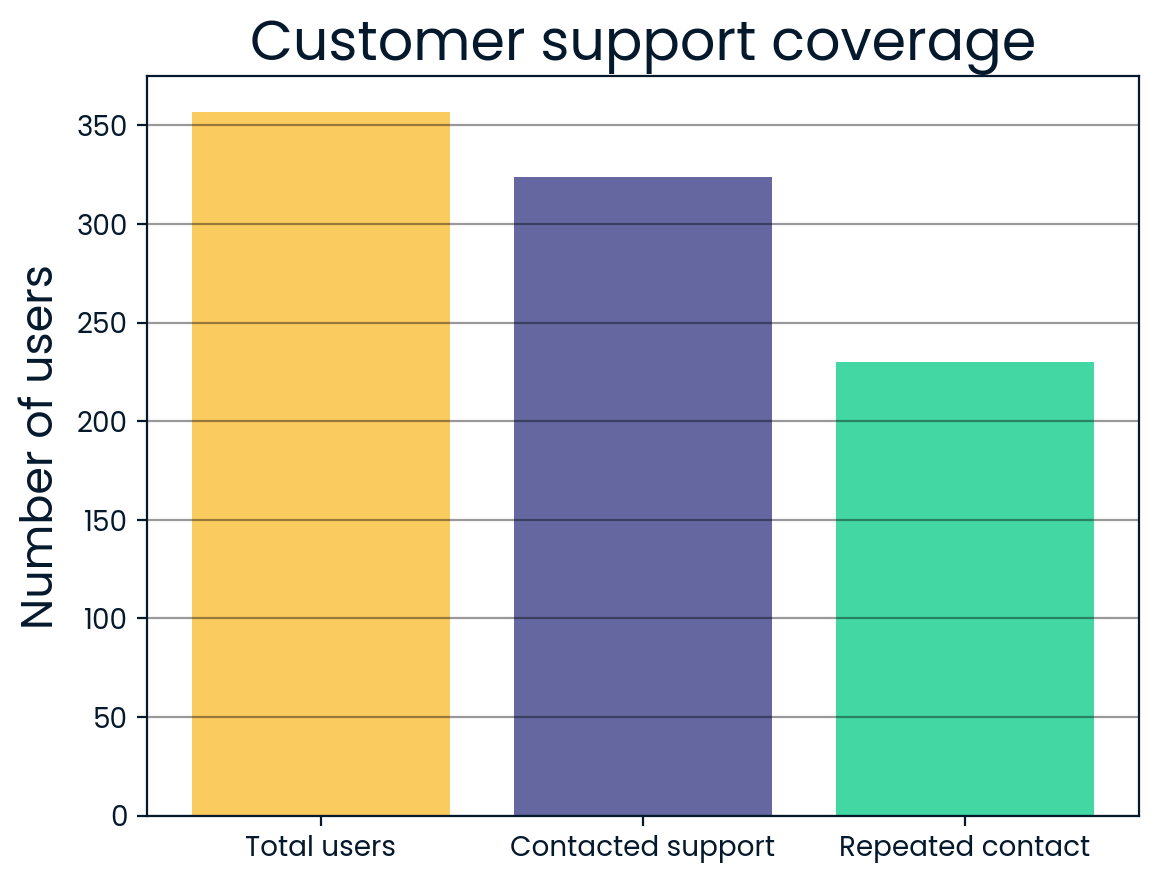

In [169]:
labels = ['Total users', 'Contacted support', 'Repeated contact']
values = [total_users, user_with_tickets, repeat_tickets_count]

plt.bar(labels, values, color = ['#facc5f', '#6568a0', '#43d7a4'])
plt.title('Customer support coverage', fontsize=20)
plt.ylabel('Number of users', fontsize=16)

plt.grid(axis='y', linestyle='-', alpha=0.4, color = 'black')
plt.show()

The percentage of customers contacting support is 90.8%. This means that 9 out of 10 customers experience some kind of issue.


I decided to examine how waiting time and issue resolution status influence a customer’s decision to leave or stay. A customer may wait too long for a response or become frustrated if their issue is not resolved, or both.


In [183]:
support_churn = pd.merge(support, accounts[['customer_id', 'churn_status']], left_on = 'user_id', right_on= 'customer_id')

# Average resolution time for churned and retained customers 

resolution_time_mean = round(support_churn.groupby('churn_status')['resolution_time_hours'].mean(), 2)
print("\nAverage resolution time for churned and retained customers (hours):")

resolution_time_mean




Average resolution time for churned and retained customers (hours):


churn_status
N     6.72
Y    18.76
Name: resolution_time_hours, dtype: float64

In [182]:
# Issue resolution status for churned and retained customers

status_pivot = round(pd.crosstab(support_churn['churn_status'], support_churn['ticket_status'], normalize = 'index') *100, 1)
print("\nPercentage of churned and retained customers by issue resolution status:")

status_pivot


Percentage of churned and retained customers by issue resolution status:


ticket_status,Resolved,Unresolved
churn_status,,
N,55.3,44.7
Y,57.1,42.9


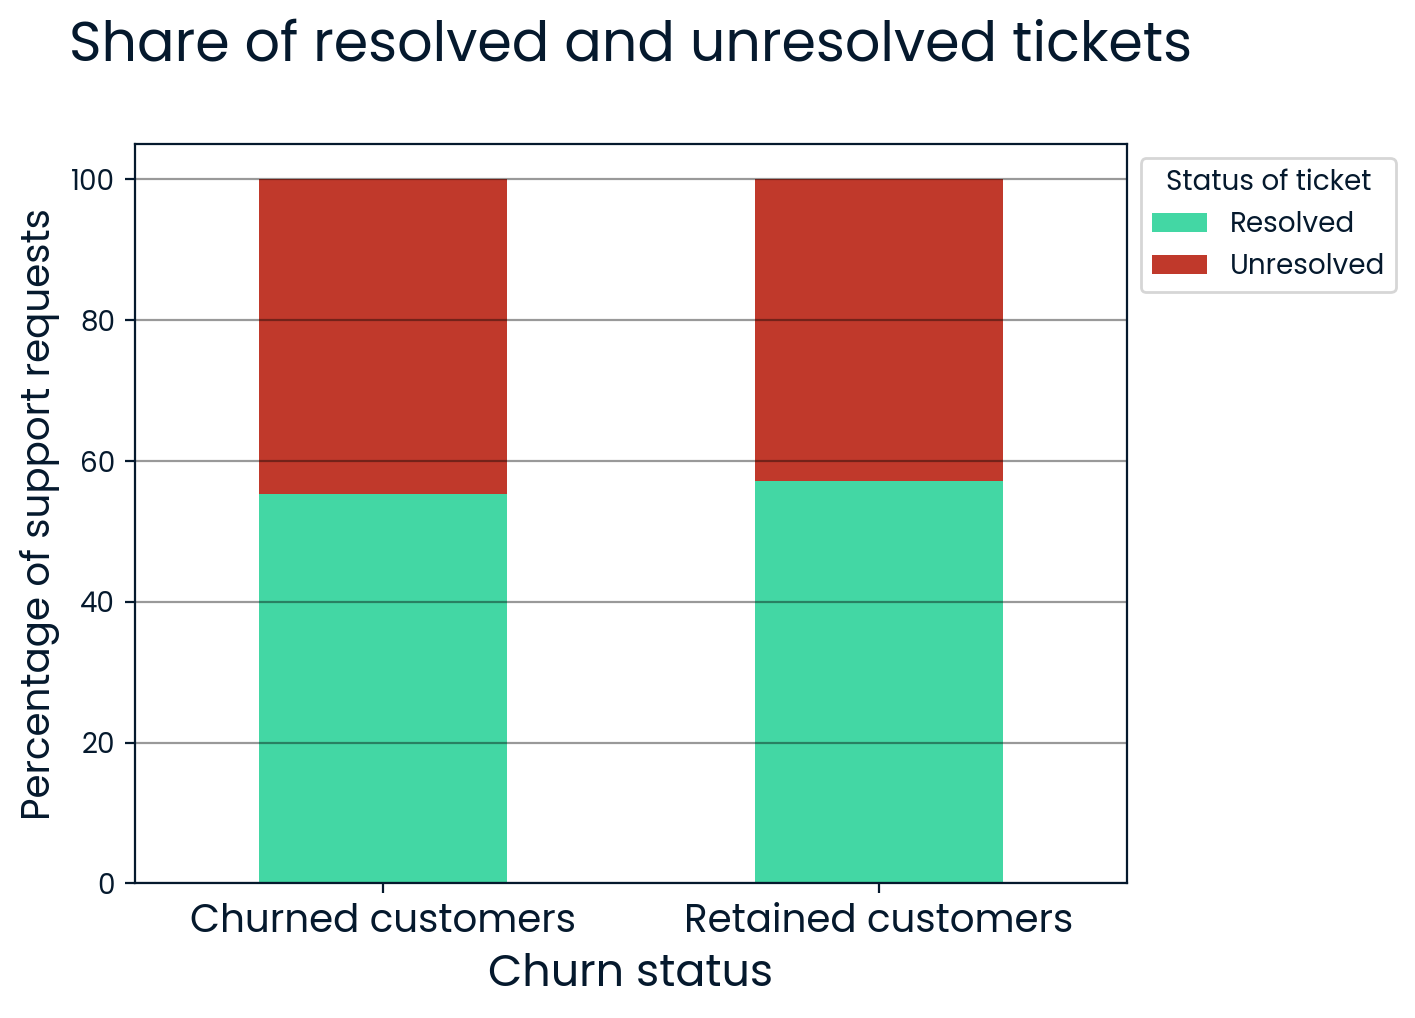

In [162]:
ax = status_pivot.plot(kind='bar', stacked=True, color=['#43d7a4', '#c0392b'])
plt.title('Share of resolved and unresolved tickets', fontsize=20, pad=30)
plt.xlabel('Churn status', fontsize=16)
plt.ylabel('Percentage of support requests', fontsize=14)
plt.xticks(rotation=0)
plt.legend(['Resolved', 'Unresolved'], title = 'Status of ticket', loc='upper left', bbox_to_anchor = (1,1)) 
ax.set_xticklabels(['Churned customers', 'Retained customers'], fontsize=14)
plt.grid(axis='y', linestyle='-', alpha=0.4, color = 'black')
plt.show()

From the chart and calculations, it is clear that the issue resolution status does not affect churn, as the proportion of resolved and unresolved issues is nearly the same between churned and retained customers.


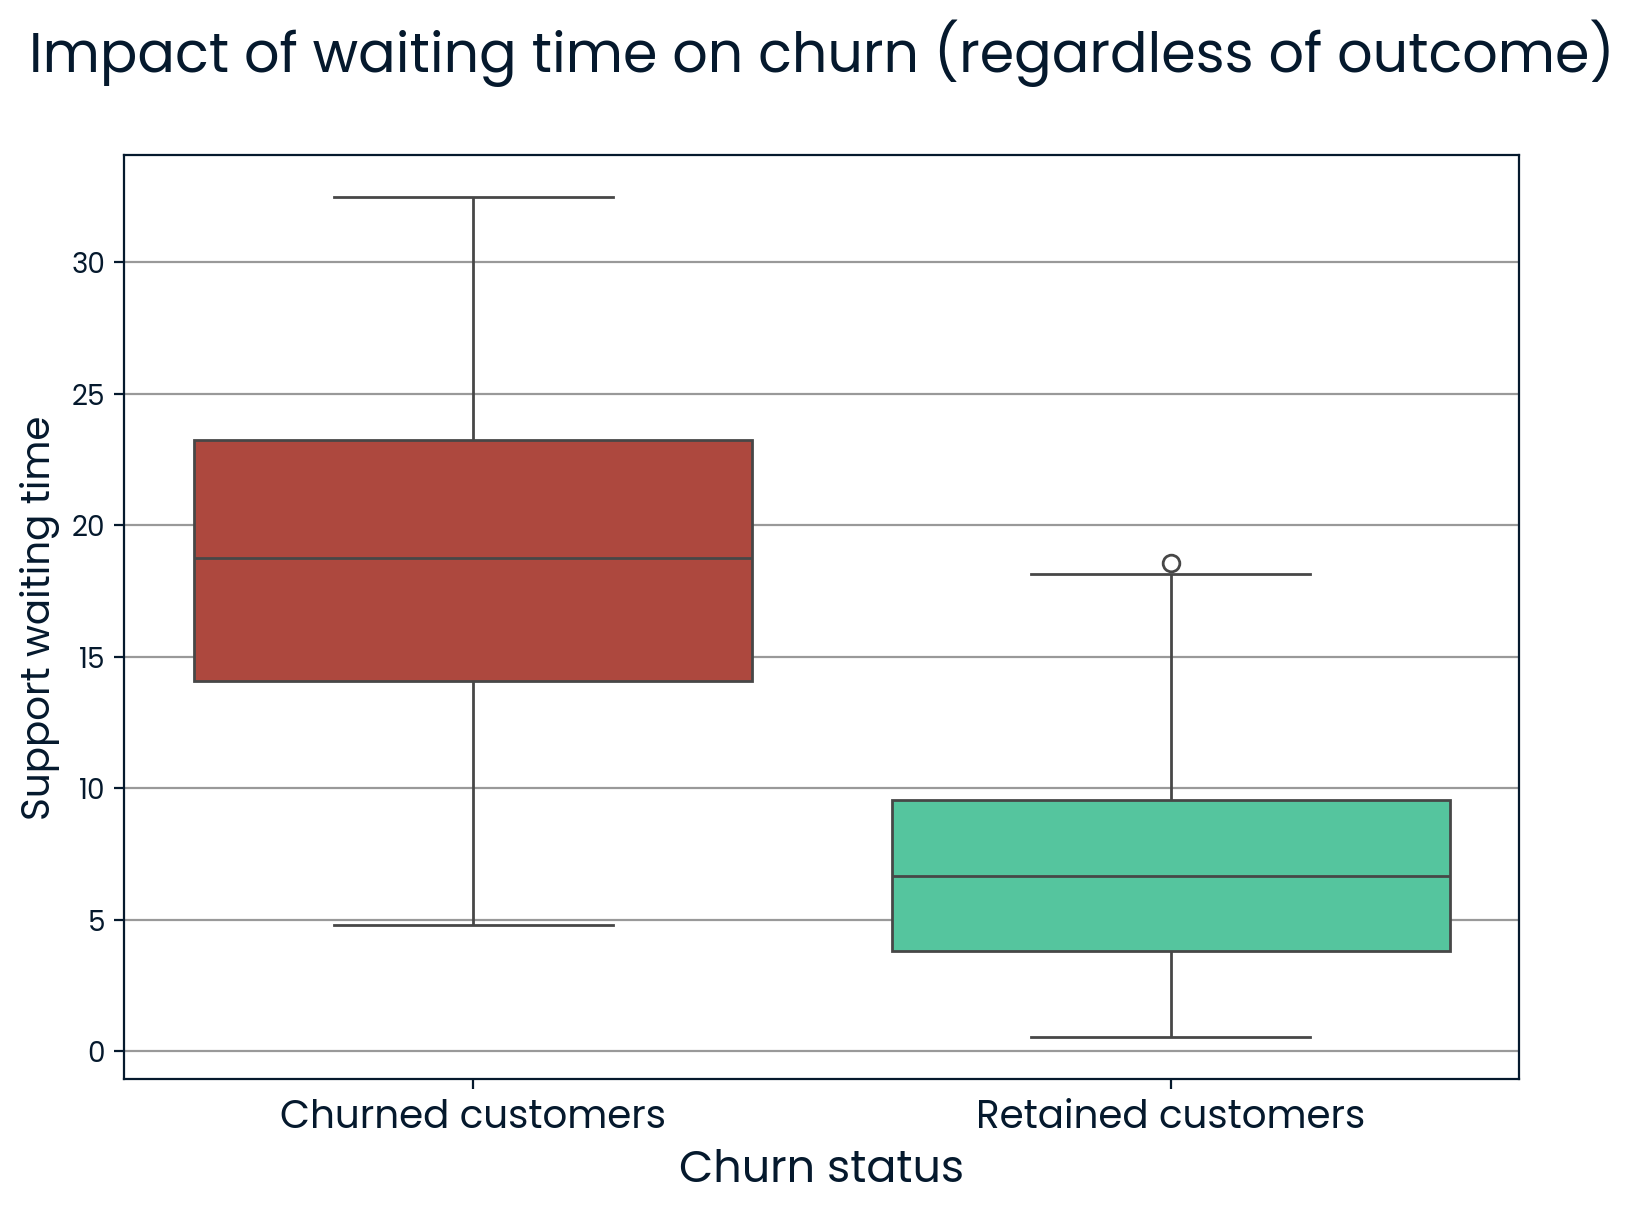

In [175]:
wait_impact = accounts.merge(support[['user_id', 'resolution_time_hours']], left_on='customer_id', right_on='user_id')

plt.figure(figsize=(9, 6))
ax = sns.boxplot(x='churn_status', y='resolution_time_hours', hue= 'churn_status', data=wait_impact, palette=[ '#c0392b', '#43d7a4'])

plt.title('Impact of waiting time on churn (regardless of outcome)', fontsize=20, pad=30)
plt.xlabel('Churn status', fontsize=16)
plt.ylabel('Support waiting time', fontsize=14)
ax.set_xticklabels(['Churned customers', 'Retained customers'], fontsize=14)
plt.grid(axis='y', linestyle='-', alpha=0.4, color = 'black')
plt.show()

The calculations also showed that customers who, on average, waited twice as long for a support resolution were more likely to leave. The issues of retained users were resolved in about 6 hours on average, which is a quarter of a day. In contrast, the average waiting time for churned users was 18 hours, which is almost a full day.

Now we need to understand what actions were taken by the customers who left.


In [179]:
import duckdb
import numpy as np

user_event = duckdb.query("""SELECT a.churn_status, a2.event_type, COUNT(DISTINCT a.customer_id) AS num_user
                          FROM accounts AS a
                          LEFT JOIN activity AS a2
                          ON a.customer_id=a2.user_id
                          GROUP BY a.churn_status, a2.event_type""").to_df()
user_event_pivot = user_event.pivot(index='churn_status', columns='event_type', values='num_user').fillna(0)
user_event_pivot =user_event_pivot.rename(columns = {np.nan: 'No Activity', None : 'No Activity'})

user_event_pivot


event_type,No Activity,Read Article,Share Workout,Track Workout,Watch Video
churn_status,,,,,
N,65,77,73,88,78
Y,70,12,4,1,15


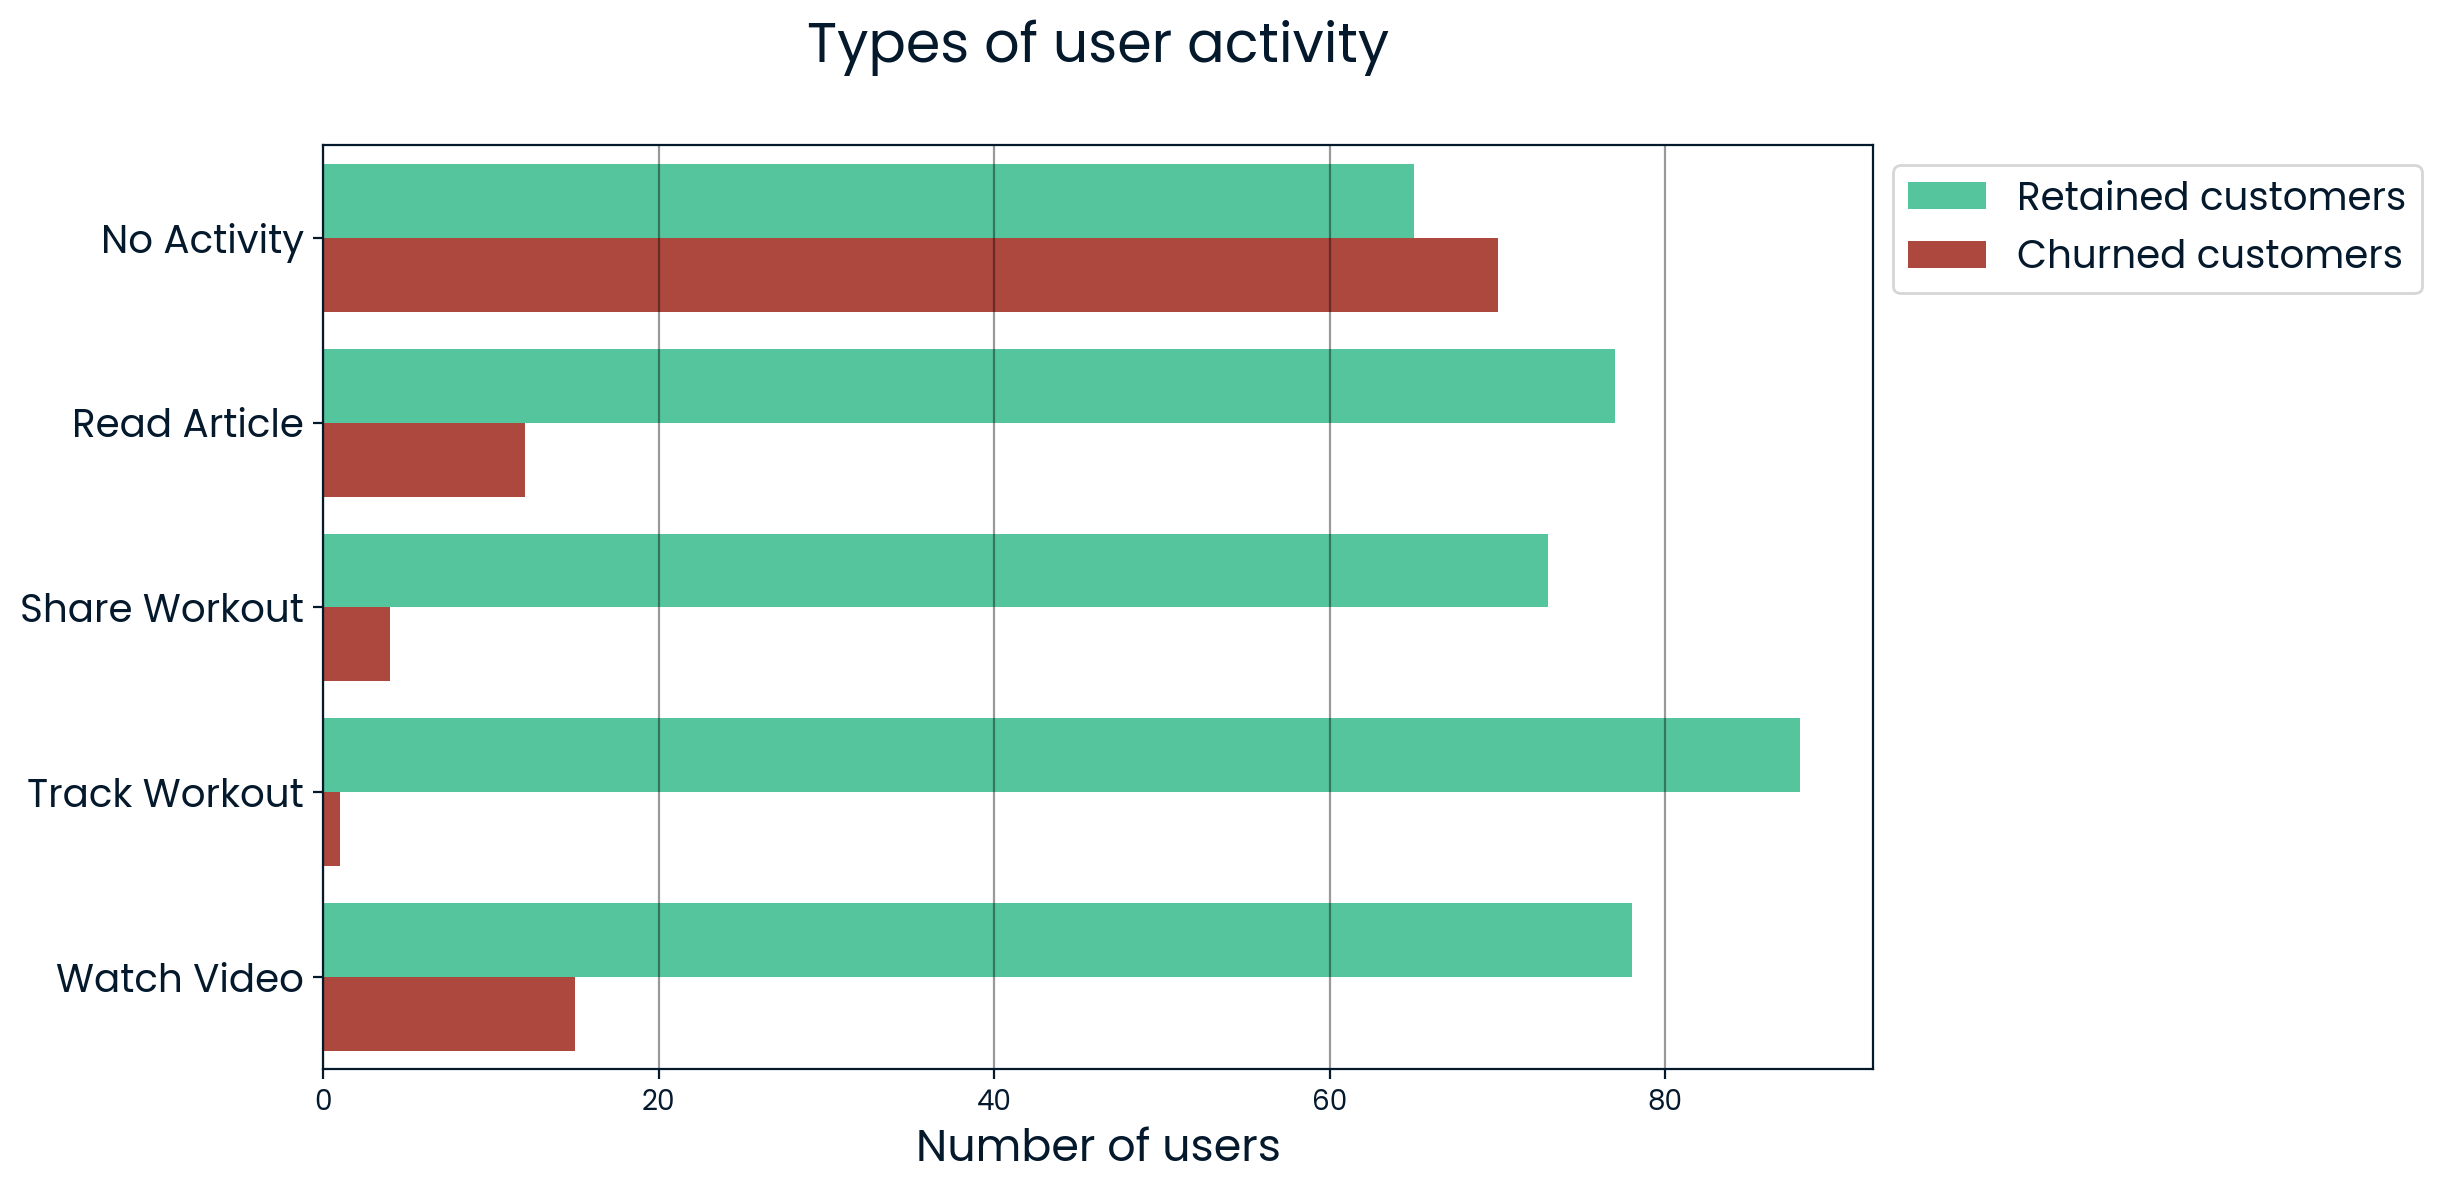

In [193]:
df = user_event_pivot.reset_index()
df = df.melt(id_vars='churn_status', var_name='event_type', value_name='num_user')

df['churn_status'] = df['churn_status'].map({
    'Y': 'Churned customers',
    'N': 'Retained customers'
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df,
    x='num_user',
    y='event_type',
    hue='churn_status', palette = ['#43d7a4', '#c0392b'] 
)
plt.legend(loc='upper left', bbox_to_anchor = (1,1), fontsize = 14)
plt.title('Types of user activity', fontsize = 20, pad=30)
plt.ylabel(None)
plt.xlabel('Number of users', fontsize = 16)

ax.tick_params(axis='y', labelsize=14)

plt.grid(axis='x', linestyle='-', alpha=0.4, color = 'black')

plt.show()

From the comparison chart of churned and retained users, it can be seen that retained users are consistently active across all events, whereas the majority of churned users do not perform any actions. This suggests that either the churned users did not start their first workout or they encountered some difficulties before getting started.

I want to find out what the customer’s last action was before leaving.


In [195]:
WITH Last_Events AS (
    SELECT 
        a.customer_id,
        a.churn_status,
        COALESCE(
            FIRST_VALUE(a2.event_type) OVER (PARTITION BY a.customer_id ORDER BY a2.event_time DESC), 
            'No Activity'
        ) AS last_event
    FROM accounts AS a
    LEFT JOIN activity AS a2 ON a.customer_id = a2.user_id
    WHERE a.churn_status = 'Y'
)
SELECT 
    last_event, 
    COUNT(DISTINCT customer_id) AS user_count,
    ROUND(COUNT(DISTINCT customer_id) * 100.0 / (SELECT COUNT(*) FROM accounts WHERE churn_status = 'Y'), 1) AS percentage
FROM Last_Events
GROUP BY last_event
ORDER BY user_count DESC

,last_event,user_count,percentage
0,No Activity,70,72.2
1,Watch Video,14,14.4
2,Read Article,10,10.3
3,Share Workout,3,3.1


From the chart, it is clear that "Track workout" does not appear at all, which means that users either left without ever starting a workout or encountered an issue before they were able to begin it.

Now let’s take a closer look at the customers who churned and did not perform any actions at all.


In [233]:
--Distribution across subscription plans of users who churned without performing any actions.

WITH last_events AS (SELECT a.plan AS plan,
        a.customer_id AS customer_id,
        a.churn_status AS churn_status,
            COALESCE(
            FIRST_VALUE(a2.event_type) OVER (PARTITION BY a.customer_id ORDER BY a2.event_time DESC), 
            'No Activity'
        ) AS last_event
    FROM accounts AS a
    LEFT JOIN activity AS a2 ON a.customer_id = a2.user_id
    WHERE a.churn_status = 'Y')

    SELECT COUNT(DISTINCT customer_id) AS total_users, 
    CASE WHEN plan IN ('Basic', 'Enterprise', 'Pro') THEN 'Subscription'
    ELSE 'Free' END AS plan_group
    FROM last_events
    WHERE last_event = 'No Activity'
    GROUP BY plan_group
    ORDER BY COUNT(DISTINCT customer_id) DESC

,total_users,plan_group
0,45,Subscription
1,25,Free


In [197]:
# How many of the churned users contacted support?

support_churn = pd.merge(support, accounts[['customer_id', 'churn_status']], left_on = 'user_id', right_on= 'customer_id')

total_users_left_with_ticket = support_churn[support_churn['churn_status'] == 'Y']['customer_id'].nunique()
total_users_left =accounts[accounts['churn_status']== 'Y']['customer_id'].nunique()
print(f"All churned users: {total_users_left}")
print(f"Churned users who contacted support: {total_users_left_with_ticket}")
print(f"Percentage of churned users who contacted support: {round(total_users_left_with_ticket / total_users_left * 100, 2)}")

All churned users: 97
Churned users who contacted support: 92
Percentage of churned users who contacted support: 94.85


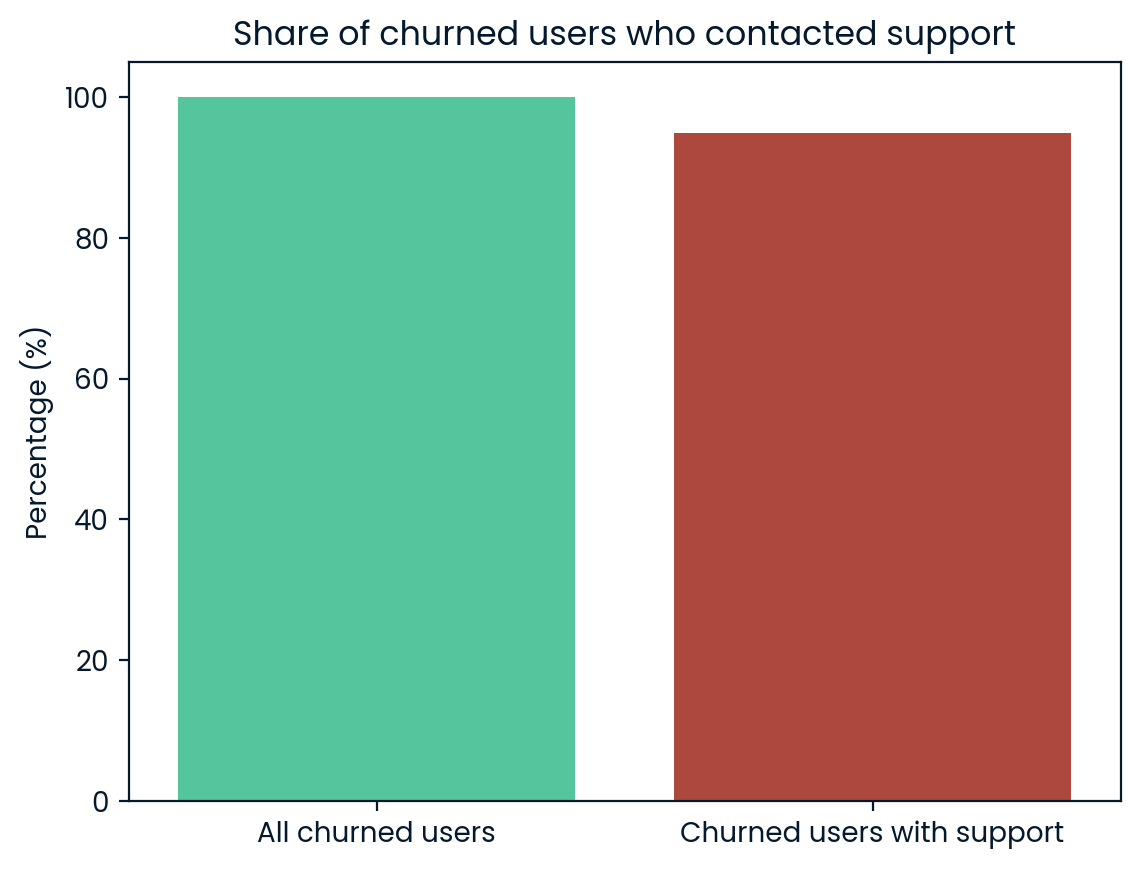

In [198]:
plot_data = pd.DataFrame({
    'group': ['All churned users', 'Churned users with support'],
    'count': [total_users_left, total_users_left_with_ticket]
})
plot_data['pct'] = round(plot_data['count'] / total_users_left * 100, 2)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=plot_data,
    x='group',
    y='pct',
    palette= ['#43d7a4', '#c0392b'] 
)

plt.title('Share of churned users who contacted support')
plt.xlabel('')
plt.ylabel('Percentage (%)')

plt.show()

I am investigating whether there is a relationship between the number of support requests from the same customer on a paid versus a free subscription and their decision to churn or stay.


In [215]:
support_corr = duckdb.query("""
SELECT 
    a.customer_id,
    a.churn_status,
    s.resolution_time_hours,
    COUNT(*) OVER (PARTITION BY a.customer_id) AS num_ticket_support,
    CASE 
        WHEN a.plan IN ('Basic', 'Enterprise', 'Pro') THEN 'Subscription'
        ELSE 'Free'
    END AS plan_group
FROM accounts a
JOIN support s 
    ON a.customer_id = s.user_id
""").to_df()

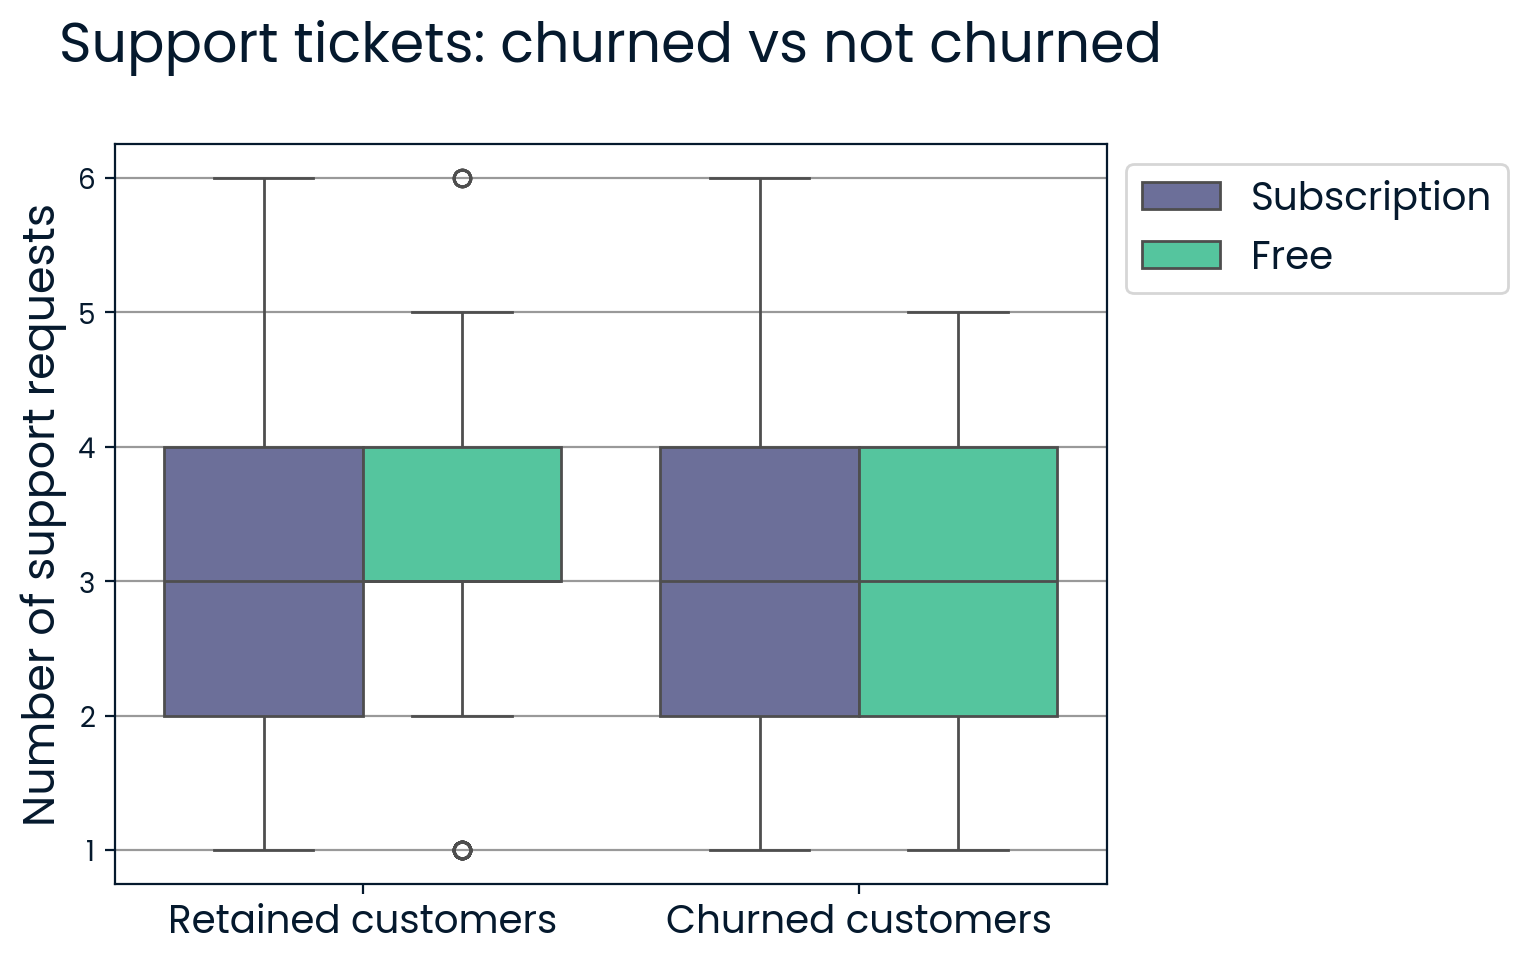

In [212]:
ax = sns.boxplot(
    data=support_corr,
    x='churn_status',
    y='num_ticket_support',
    hue='plan_group'
)

plt.title('Support tickets: churned vs not churned', fontsize=20, pad=30)
plt.ylabel('Number of support requests', fontsize=16)
plt.xlabel(None)
ax.set_xticklabels([ 'Retained customers', 'Churned customers'], fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor = (1,1), fontsize = 14)
plt.grid(axis='y', linestyle='-', alpha=0.4, color = 'black')
plt.show()

No clear relationship is observed.


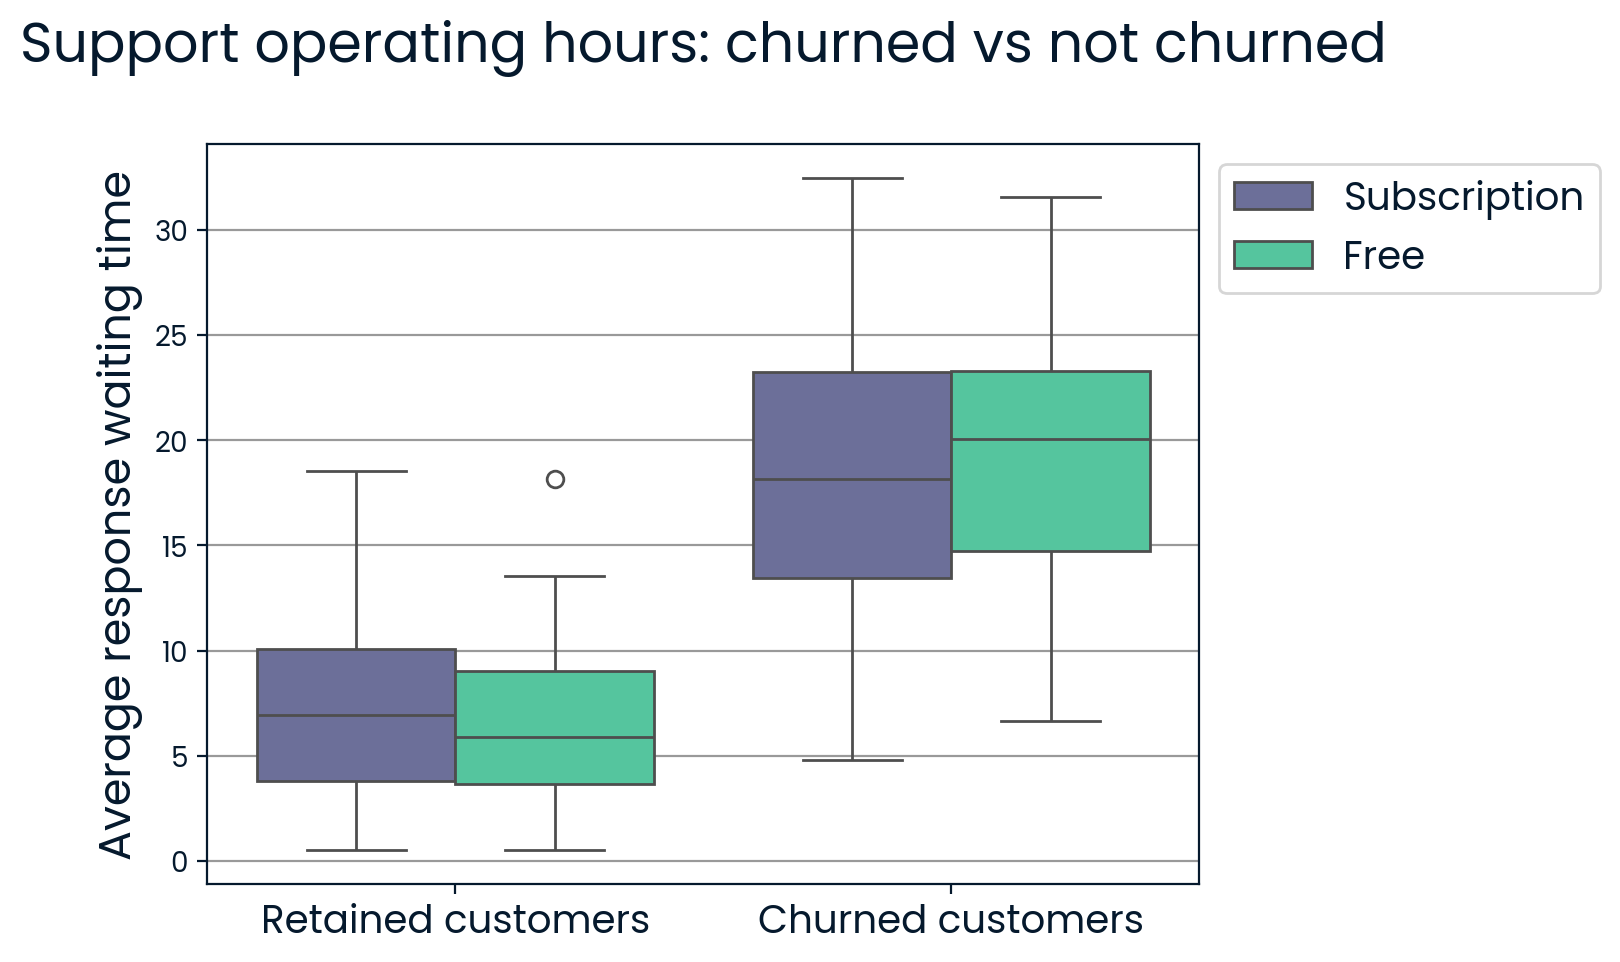

In [213]:
ax = sns.boxplot(
    data=support_corr,
    x='churn_status',
    y='resolution_time_hours',
    hue='plan_group'
)

plt.title('Support operating hours: churned vs not churned', fontsize=20, pad=30)
plt.ylabel('Average response waiting time', fontsize=16)
plt.xlabel(None)
ax.set_xticklabels([ 'Retained customers', 'Churned customers'], fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor = (1,1), fontsize = 14)
plt.grid(axis='y', linestyle='-', alpha=0.4, color = 'black')
plt.show()

Finally, I will compare the support response waiting time for inactive users who decided to stay.


In [247]:
WITH no_act_rat_user AS (SELECT a.churn_status AS churn_status,
ROUND(AVG(s.resolution_time_hours),2) AS resolution_time_hours,
CASE WHEN a2.event_type IS NULL THEN 'No Activity'
ELSE 'Active' END AS event_type
FROM accounts AS a
	
LEFT JOIN activity AS a2
ON a.customer_id = a2.user_id
LEFT JOIN support AS s
ON a.customer_id = s.user_id
	
GROUP BY a.churn_status, event_type)

SELECT *
FROM no_act_rat_user
WHERE event_type = 'No Activity'



,churn_status,resolution_time_hours,event_type
0,Y,18.72,No Activity
1,N,6.09,No Activity


From the last query, it is visible that among users with no activity and support requests, those who churned had an average waiting time of over 18 hours, while those who stayed had an issue resolution time of around 6 hours.


### Overall conclusion and business recommendations


The analysis suggests that user churn is strongly associated with early-stage inactivity and support experience.

Inactive users who never started a workout are more likely to churn, indicating that the onboarding phase is critical. A significant share of users leave before completing their first action, which points to either onboarding friction or unclear initial value.

Analysis of interactions with customer support does not show a clear relationship between the number of support requests, issue resolution status, and churn. However, support response time appears to be an important distinguishing factor: churned users experienced significantly longer resolution times (around 18+ hours), while inactive users who stayed received much faster resolutions (around 6 hours).


**Recommendations**

- Improve onboarding and first workout flow: it looks like most users contact support, which suggests the path to the first workout is either blocked or not intuitive. Make the first steps clearer and easier to complete.
  
- Reduce support response time, especially for new users: faster resolution is associated with better retention.
  
- Give higher priority to users who have not yet performed any actions, as they are the highest-risk churn group.
  
- Identify and fix blockers in the "first workout" journey, since users seem to struggle before even starting.
  
- Add the user registration time to the activity table to enable tracking of multiple metrics: the time from registration to the first event, and the time from registration to contacting support.

**Monitoring progress and success**

To evaluate the effectiveness of the implemented changes, the business should track the following key metric:

- **Main metric:** Average Resolution Time (ART) — the average time to resolve a support ticket.
  
- **Target:** Reduce ART from 18 hours to 6 hours. A decrease in this metric will be a direct indicator of an improved customer experience in the high-risk segment.
  
- **Product indicator:** Reduction in the number of inactive users. A decrease in this metric will confirm that onboarding barriers have been successfully removed.

This approach will ensure continuous monitoring of churn reduction efforts and allow for rapid adjustments to the strategy for supporting new users.


